## Check for spatial localization patterns of neuron subsets

There is evidence that neuron subsets of the same type localize with each other more than with other subsets (Krauter... Enfors et al., 202) https://www.nature.com/articles/s42003-025-08315-1#Sec2

"To establish whether there is a spatial context of neuron types relative to each other, we quantified pairwise spatial proximity as a neighbor score, with 1 indicating maximum co-localization and 0 indicating no spatial overlap. This revealed that neurons of the same type and those with closer hierarchical relationships displayed closer proximity to each other than to more distantly related types (Supplementary Fig. S6c)."

Do we see evidence for this in our spatial dataset? 

In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-19 10:56:05.103398


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
import squidpy as sq

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [4]:
# plt.rcdefaults()

In [5]:
# plt.rcParams['figure.figsize'] = (4,4)
# plt.rcParams['figure.figsize'] = (3,3)
# plt.rcParams["figure.dpi"] = 300

In [6]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [7]:
base_dir = "/home/workspace/DRG"

# neurons
input_file = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"
# global 
input_file_global = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"

output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")
plot_out_dir = os.path.join(output_dir, "plots")

# updated reporter identification
# reporter_classes_updated_dual_neurons = pd.read_csv(os.path.join(output_dir, 'reporter_classes_updated_dual_neurons.csv'), index_col = 0)
# reporter status table
reporters_path = os.path.join(output_dir, "reporter_classes_gaussian_thresholds.csv")

In [8]:
# neurons
adata = sc.read_h5ad(input_file)

# global
adata_global = sc.read_h5ad(input_file_global)

In [9]:
# add the updated neuron labels to global object so that we can see where they are on the global umap
adata_global.obs = adata_global.obs.join(adata.obs[['neuron_label']])

In [10]:
print(adata.shape)
print(adata_global.shape)

(22411, 475)
(147036, 475)


In [13]:
reporter_classes_updated_dual = pd.read_csv(reporters_path, index_col = 0)
reporter_classes_updated_dual.head()

cols_update = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']
for col in cols_update:
    if col in adata.obs.columns:
        del adata.obs[col]

# add individual reporter columns
adata.obs = adata.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])

In [14]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,22120
1,True,False,False,139
2,False,True,False,133
3,True,True,True,19


## Visualization


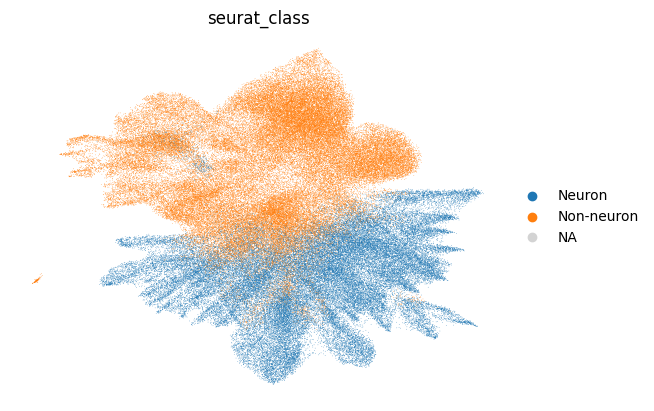

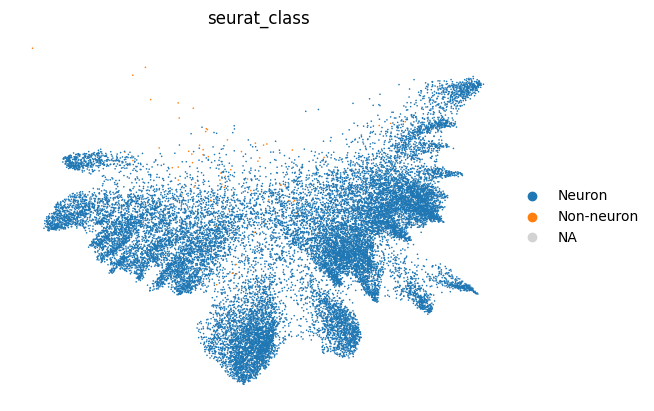

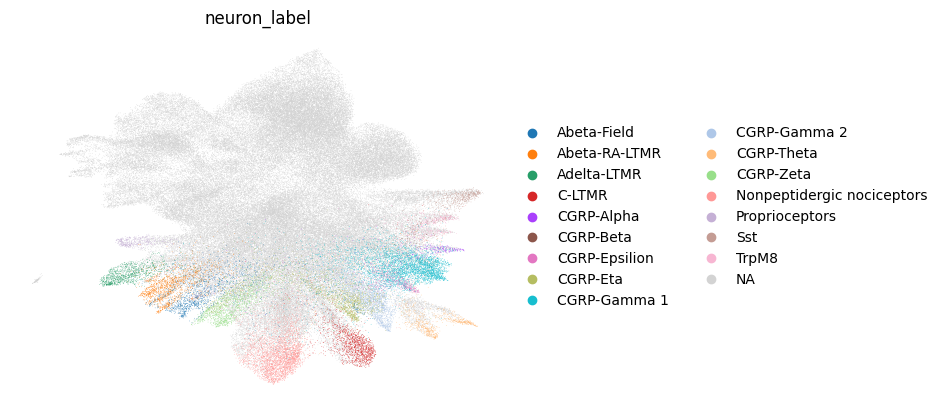

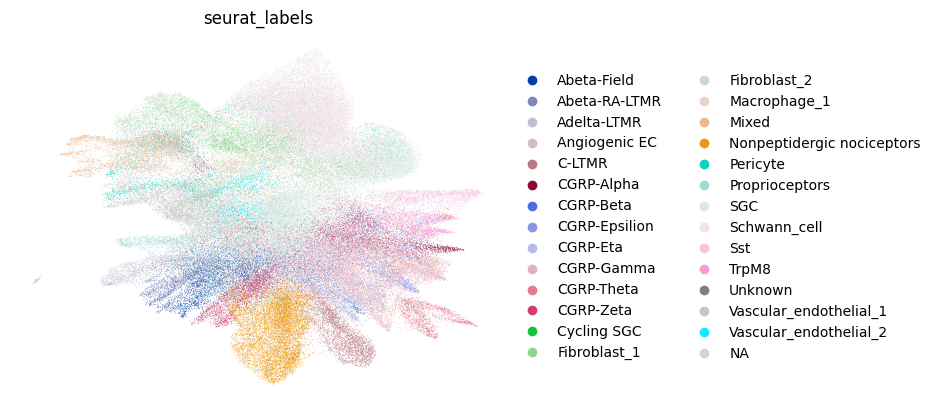

In [15]:
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global[adata_global.obs['total_counts']>1000, :], basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'neuron_label', frameon=False)
sc.pl.embedding(adata_global, basis = 'X_umap', color = 'seurat_labels', frameon=False)


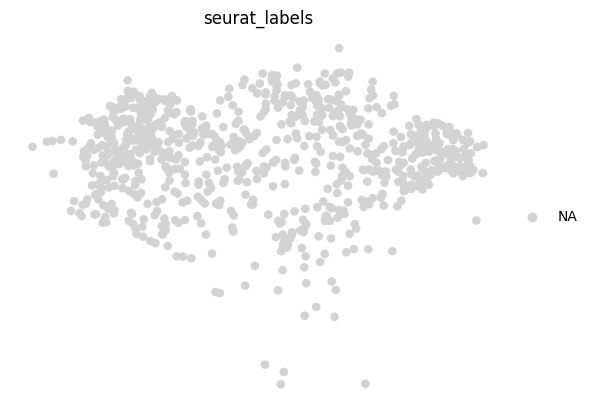

In [16]:
nan_mask = adata_global.obs['seurat_labels'].isna()
sc.pl.embedding(adata_global[nan_mask, :], basis = 'X_umap', color = 'seurat_labels', frameon=False)

### How many neurons were removed by the 1000 tran/cell filter?

In [17]:
# adata_global

In [18]:
n_neuron = sum(adata_global.obs['seurat_class']=='Neuron')
n_neuron_filt = sum( (adata_global.obs['seurat_class']=='Neuron') & (adata_global.obs['total_counts']>=1000))
print(n_neuron)
print(n_neuron_filt)
print(adata.shape)

63591
22411
(22411, 475)


## Plot neuron cell type proportions

In [19]:
neuron_label_palette_mapped = dict(zip(
    adata.obs['neuron_label'].cat.categories, 
    adata.uns['neuron_label_colors']
))

In [20]:
adata.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch',
       '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels',
       'seurat_labels', 'prediction.score.CGRP.Theta',
       'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha',
       'prediction.score.Nonpeptidergic.nociceptors',
       'prediction.score.C.LTMR', 'prediction.score.Sst',
       'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion',
       'prediction.score.

In [21]:
# 1. Prepare data and handle NaNs
df = adata.obs[["neuron_label", "cell_area"]].copy()
df["neuron_label"] = df["neuron_label"].astype(str).replace(["nan", "None"], "Unknown")


group_area = df.groupby("neuron_label")['cell_area'].sum()
total_area = group_area.sum()

group_area

neuron_label
Abeta-Field                   375074.193146
Abeta-RA-LTMR                 395685.628738
Adelta-LTMR                   277155.209592
C-LTMR                        264237.044592
CGRP-Alpha                     34437.557344
CGRP-Beta                      19682.887589
CGRP-Epsilion                 104117.130654
CGRP-Eta                      438442.277165
CGRP-Gamma 1                  822563.299546
CGRP-Gamma 2                  431364.712064
CGRP-Theta                    196729.261204
CGRP-Zeta                     389014.921465
Nonpeptidergic nociceptors    802515.639756
Proprioceptors                206623.582969
Sst                           102342.444809
TrpM8                          97896.224804
Name: cell_area, dtype: float64

In [22]:
import matplotlib.pyplot as plt
def barplot_cell_composition(
    adata,
    use_area = False,
    palette = None, 
    group_col="neuron_label",
    area_col = "cell_area",
    figsize=(4, 4),
    fontsize=11,
    plot_counts=True,
    return_group_order=False,
    group_order=None,
):
    # 1. Prepare data and handle NaNs
    df = adata.obs[[group_col, area_col]].copy()
    df[group_col] = df[group_col].astype(str).replace(["nan", "None"], "Unknown")

    if use_area:
        print('using area')
        group_counts = df.groupby(group_col)['cell_area'].sum()
        total_cells = group_area.sum()
    else:
        print('using counts')
        group_counts = df.groupby(group_col).size()
        total_cells = group_counts.sum()
    
    # 3. Calculate percentages
    stats = (group_counts / total_cells * 100)

    # 4. Handle ordering
    if group_order is not None:
        stats = stats.reindex(group_order).fillna(0)
    else:
        stats = stats.sort_values(ascending=False)
    
    # Ensure sorted_counts matches the final order of stats
    final_order = stats.index.tolist()
    sorted_counts = group_counts.reindex(final_order).fillna(0)

    # 5. Plotting
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(stats))

    if palette is not None:
        # Create a list of colors that follows final_order
        # Default to 'gray' if the category isn't in the palette
        bar_colors = [palette.get(cls, "gray") for cls in final_order]
    else:
        bar_colors = "steelblue" # Default color if no palette provided

    if plot_counts:
        ax.bar(x, sorted_counts.values, alpha=0.9, color = bar_colors)
        ax.set_ylabel("Count", fontsize=fontsize)
    else:
        ax.bar(x, stats.values, alpha=0.9, color = bar_colors)
        ax.set_ylabel("Percent", fontsize=fontsize)
        # ax.set_ylim(0, 100)
    if use_area:
        ax.set_title("Composition by area", fontsize=fontsize)
    else:
        ax.set_title("Composition by counts", fontsize=fontsize)

    # Styling
    ax.set_xticks(x)
    ax.set_xticklabels(final_order, rotation=45, ha="right", fontsize=fontsize)
    ax.set_xlabel("")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout() # Better alternative to manual subplots_adjust

    if return_group_order:
        return fig, final_order
    return fig

using counts
using counts
using area


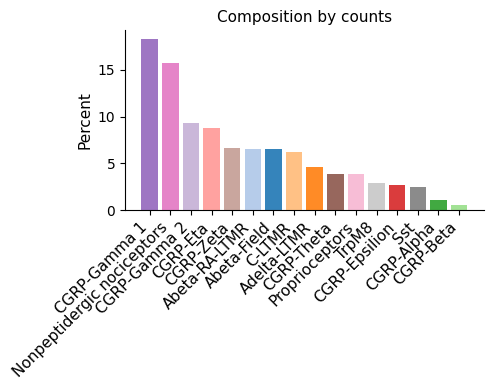

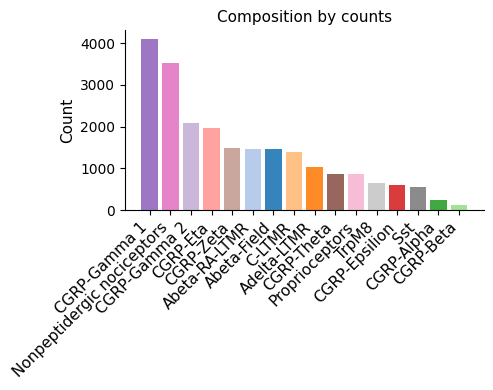

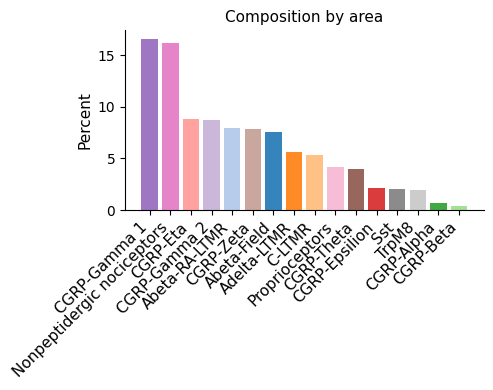

In [23]:
p1 = barplot_cell_composition(
    adata,
    palette = neuron_label_palette_mapped,
    group_col="neuron_label",
plot_counts = False,
figsize=(5, 4))
plt.savefig(os.path.join(plot_out_dir, "cell_composition_bycounts.pdf"), format='pdf', bbox_inches='tight')

p1 = barplot_cell_composition(
    adata,
    palette = neuron_label_palette_mapped,
    group_col="neuron_label",
plot_counts = True,
figsize=(5, 4))
plt.savefig(os.path.join(plot_out_dir, "cell_composition_bycounts_absolute_counts.pdf"), format='pdf', bbox_inches='tight')

p2 = barplot_cell_composition(
    adata,
    use_area = True,
    palette = neuron_label_palette_mapped,
    group_col="neuron_label",
    area_col="cell_area",
plot_counts = False,
    figsize=(5, 4))
plt.savefig(os.path.join(plot_out_dir, "cell_composition_byarea.pdf"), format='pdf', bbox_inches='tight')

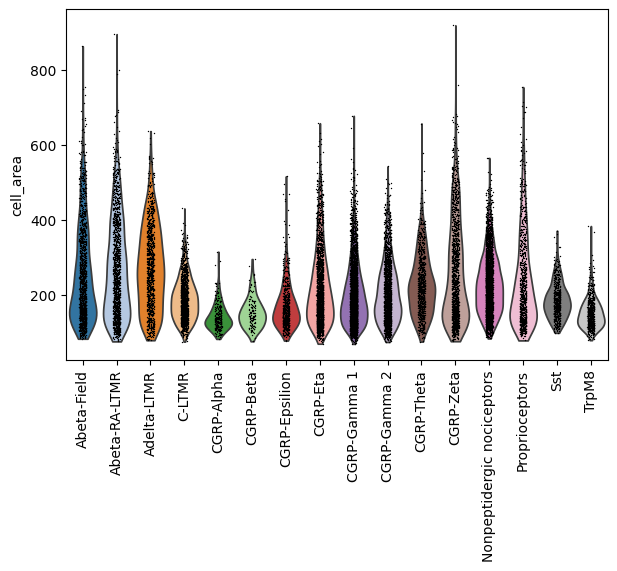

In [24]:
sc.pl.violin(adata, groupby = 'neuron_label', keys='cell_area', rotation = 90, show=False)
plt.savefig(os.path.join(plot_out_dir, "cell_area_violin.pdf"), format='pdf', bbox_inches='tight')



/tmp/ipykernel_108/3199322243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_df = pd.DataFrame(area_df.groupby('neuron_label')['cell_area'].mean())


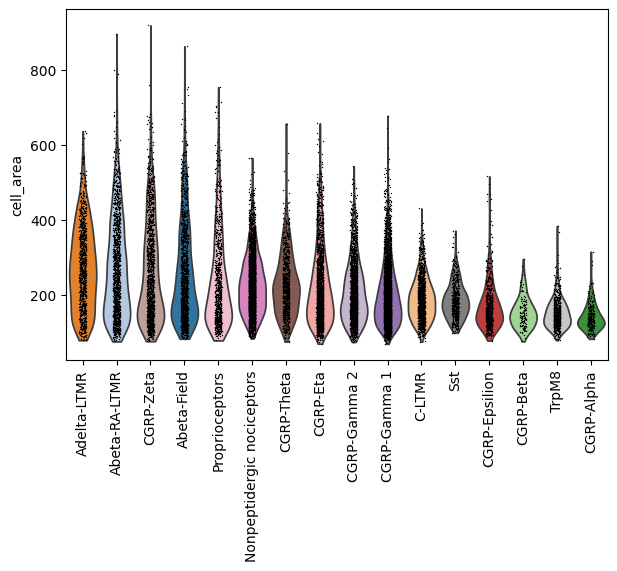

In [25]:
area_df = adata.obs[['neuron_label', 'cell_area']].copy()
area_df = pd.DataFrame(area_df.groupby('neuron_label')['cell_area'].mean())
area_df = area_df.sort_values(by='cell_area', ascending = False)
order_area = area_df.index.tolist()
sc.pl.violin(adata, groupby = 'neuron_label', keys='cell_area', rotation = 90, order = order_area, show=False)
plt.savefig(os.path.join(plot_out_dir, "cell_area_violin_ordered.pdf"), format='pdf', bbox_inches='tight')

## Spatial plots

In [26]:
# palette for label plotting
import pickle
with open(os.path.join(output_dir, 'neuron_label_palette_mapped.pkl'), 'rb') as f:
    neuron_label_palette_mapped = pickle.load(f)

with open(os.path.join(output_dir, 'neuron_label_palette_mapped_ginty.pkl'), 'rb') as f:
    neuron_label_palette_mapped_ginty = pickle.load(f)

In [31]:
sample = 'TMA00312'
# sample = 'TMA00305'
adata_temp = adata_global[adata_global.obs['sample_id'] == sample, :].copy()
# Flip the y-coordinates by multiplying the second column by -1
# adata_temp.obsm['spatial'][:, 1] = adata_temp.obsm['spatial'][:, 1] * -1

In [49]:
neuron_label_palette_mapped_grey = neuron_label_palette_mapped.copy()
neuron_label_palette_mapped_grey = {key: 'lightgray' for key in neuron_label_palette_mapped_grey.keys()}

In [51]:
neuron_label_palette_mapped_grey

{'Abeta-Field': 'lightgray',
 'Abeta-RA-LTMR': 'lightgray',
 'Adelta-LTMR': 'lightgray',
 'C-LTMR': 'lightgray',
 'CGRP-Alpha': 'lightgray',
 'CGRP-Beta': 'lightgray',
 'CGRP-Epsilion': 'lightgray',
 'CGRP-Eta': 'lightgray',
 'CGRP-Gamma 1': 'lightgray',
 'CGRP-Gamma 2': 'lightgray',
 'CGRP-Theta': 'lightgray',
 'CGRP-Zeta': 'lightgray',
 'Nonpeptidergic nociceptors': 'lightgray',
 'Proprioceptors': 'lightgray',
 'Sst': 'lightgray',
 'TrpM8': 'lightgray'}

In [69]:
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

def plot_neuron_zoom(adata, label_celltypes=None, x_lims=None, y_lims=None, 
                     palette=None, bg_color='lightgray', spot_size_labeled=80, 
                     spot_size_bg=20):
    """
    Plots a zoomed-in spatial view with highlighted cell types and a grey background.
    """
    # 1. Setup Figure
    fig, ax = plt.subplots()
    
    # 2. Handle Logic for Labeled vs Unlabeled
    if label_celltypes:
        # Layer 1: The background (Other cells)
        # We use .copy() to avoid ImplicitModificationWarning
        adata_bg = adata[~adata.obs['neuron_label'].isin(label_celltypes), :].copy()
        adata_bg.obs['bg_color'] = 'background'
        
        sc.pl.embedding(
            adata_bg, basis='spatial', color='bg_color', 
            palette={'background': bg_color}, size=spot_size_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none'
        )
        
        # Layer 2: The high-quality neurons (Highlighted)
        adata_labeled = adata[adata.obs['neuron_label'].isin(label_celltypes), :].copy()
        sc.pl.embedding(
            adata_labeled, basis='spatial', color='neuron_label', 
            palette=palette, size=spot_size_labeled,
            show=False, frameon=False, title='', ax=ax
        )
    else:
        # Default behavior: Plot all non-NaN neurons colored, NaNs as grey
        adata_neurons = adata[~adata.obs['neuron_label'].isna(), :].copy()
        sc.pl.embedding(
            adata_neurons, basis='spatial', color='neuron_label', 
            palette=palette, size=spot_size_labeled,
            show=False, frameon=False, title='', ax=ax
        )
        
        adata_nan = adata[adata.obs['neuron_label'].isna(), :].copy()
        sc.pl.embedding(
            adata_nan, basis='spatial', color='neuron_label', 
            palette=palette, size=spot_size_bg,
            show=False, frameon=False, title='', ax=ax, legend_loc = 'none'
        )

    # 3. Apply Zoom and Aspect Ratio
    ax.set_aspect('equal', adjustable='box')
    
    if x_lims:
        ax.set_xlim(x_lims)
    if y_lims:
        ax.set_ylim(y_lims)
    
    # Standard Xenium coordinate inversion
    ax.invert_yaxis()
    
    return fig, ax



(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='spatial1', ylabel='spatial2'>)

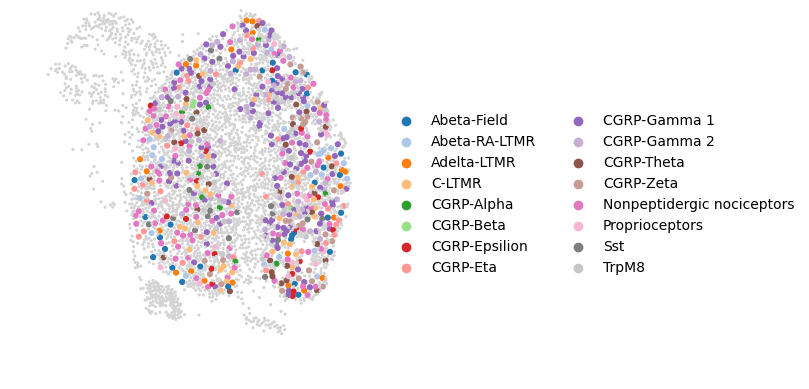

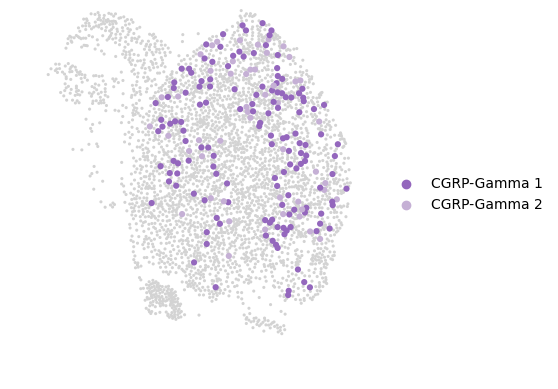

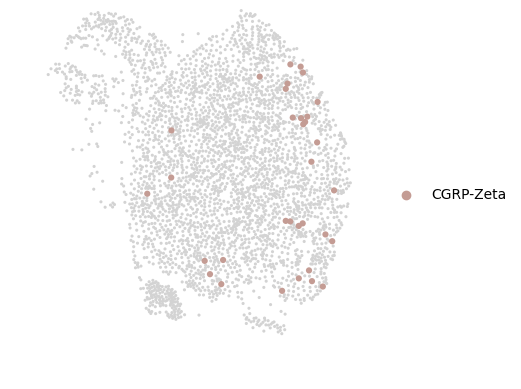

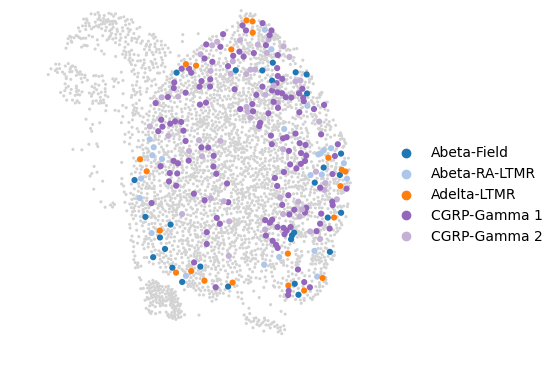

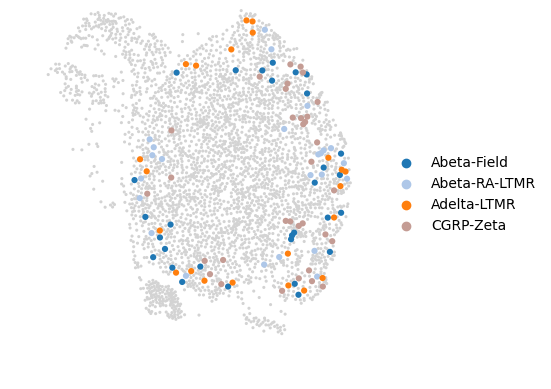

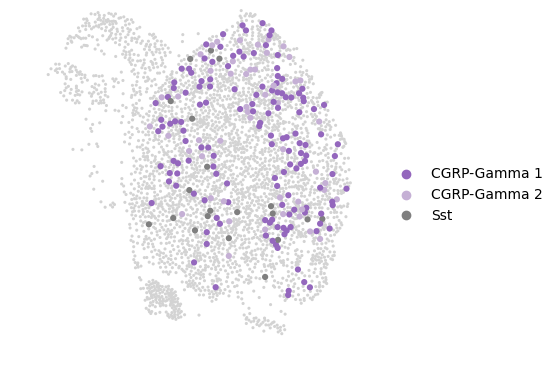

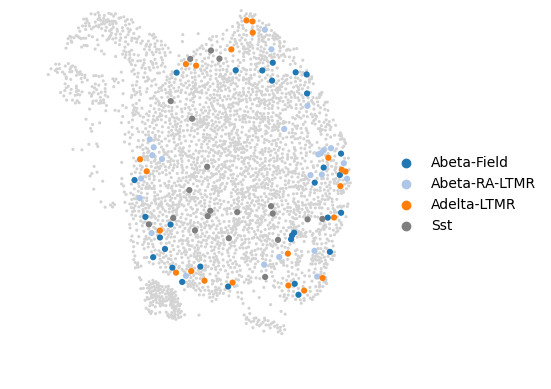

In [76]:
plot_neuron_zoom(
    adata_temp, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['CGRP-Gamma 1', 'CGRP-Gamma 2']
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['CGRP-Zeta']
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['CGRP-Gamma 1', 'CGRP-Gamma 2', 'Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR']
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['CGRP-Zeta', 'Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR']
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['Sst', 'CGRP-Gamma 1', 'CGRP-Gamma 2', ]
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

label_list = ['Sst', 'Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR']
plot_neuron_zoom(
    adata_temp, 
    label_celltypes=label_list, 
    x_lims=(4300, 5300), 
    y_lims=(2800, 3800),
    palette=neuron_label_palette_mapped
)

In [ ]:

# showing only high quality neurons
fig, ax = plt.subplots()

#  high quality neurons - specific cell type
sc.pl.embedding(adata_temp[~adata_temp.obs['neuron_label'].isna(), :], 
                basis = 'spatial', color = 'neuron_label', palette = neuron_label_palette_mapped, size = 80, 
                show = False, frameon=False, title='',
               ax=ax)

#  other cells
sc.pl.embedding(adata_temp[adata_temp.obs['neuron_label'].isna(), :], 
                basis = 'spatial', color = 'neuron_label', palette = neuron_label_palette_mapped, size = 20,
                # alpha = 0.5,
                show = False, frameon=False, title='',
               ax=ax)


ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
# TMA00305
# plt.xlim(5600, 6600)
# plt.ylim(2100,3100)
#TMA00312
plt.xlim(4300, 5300)
plt.ylim(2800, 3800)
ax.invert_yaxis()

AttributeError: module 'matplotlib.pyplot' has no attribute 'invert_yaxis'

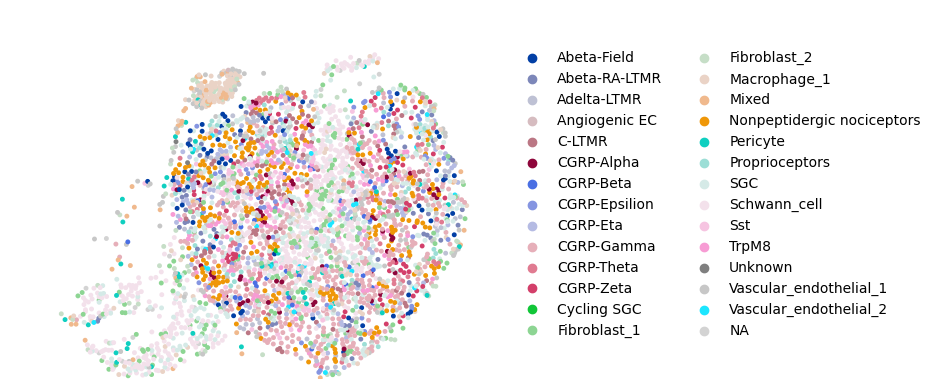

In [34]:
# showing labels before neuron filtering
sc.pl.embedding(adata_temp, basis = 'spatial', color = 'seurat_labels', size = 50, show = False, frameon=False, title='')
plt.gca()
# TMA00305
# plt.xlim(5600, 6600)
# plt.ylim(-3100, -2100)
#TMA00312
plt.xlim(4300, 5300)
# plt.ylim(-3800, -2800)
plt.ylim(2800, 3800)
plt.invert_yaxis()
plt.show()

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/scanpy/plotting/_utils.py:488: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


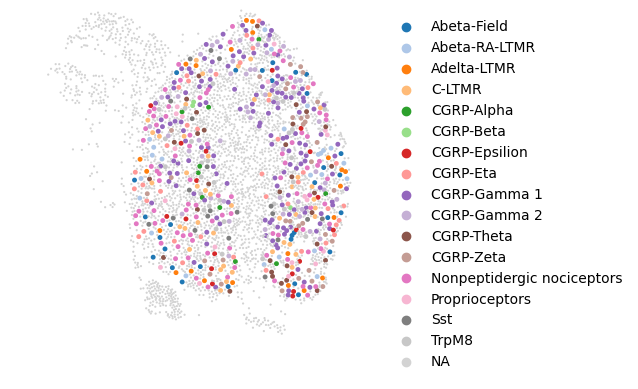

In [37]:
# showing only high quality neurons
fig, ax = plt.subplots()

#  high quality neurons
sc.pl.embedding(adata_temp[~adata_temp.obs['neuron_label'].isna(), :], 
                basis = 'spatial', color = 'neuron_label', palette = neuron_label_palette_mapped, size = 50, 
                show = False, frameon=False, title='',
               ax=ax)

#  other cells
sc.pl.embedding(adata_temp[adata_temp.obs['neuron_label'].isna(), :], 
                basis = 'spatial', color = 'neuron_label', palette = neuron_label_palette_mapped, size = 10,
                # alpha = 0.5,
                show = False, frameon=False, title='',
               ax=ax)


ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
# TMA00305
# plt.xlim(5600, 6600)
# plt.ylim(-3100, -2100)
#TMA00312
plt.xlim(4300, 5300)
plt.ylim(2800, 3800)
ax.invert_yaxis()



In [ ]:
# showing all neurons

fig, ax = plt.subplots()

#  all neurons
sc.pl.embedding(adata_temp[adata_temp.obs['seurat_class']== "Neuron", :], 
                basis = 'spatial', color = 'seurat_labels', palette = neuron_label_palette_mapped_ginty, size = 50, 
                show = False, frameon=False, title='',
               ax=ax)

#  other cells
sc.pl.embedding(adata_temp[adata_temp.obs['seurat_class']== "Non-neuron", :], 
                basis = 'spatial', color = 'neuron_label', palette = neuron_label_palette_mapped_ginty, size = 10,
                # alpha = 0.5,
                show = False, frameon=False, title='',
               ax=ax)


ax = plt.gca()
# TMA00305
# plt.xlim(5600, 6600)
# plt.ylim(-3100, -2100)
#TMA00312
plt.xlim(4300, 5300)
plt.ylim(-3800, -2800)



## Squidy spatial analysis 


### Running on global adata

In [53]:
# run neighbor graph
sq.gr.spatial_neighbors(adata_global, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        delaunay = True)

In [54]:
# remove the small number of cells with nan labels
nan_mask = adata_global.obs['seurat_labels'].isna()
print(f"number of cells with seurat_labels = nan (removing): {sum(nan_mask)}")
adata_global_prox = adata_global[~nan_mask, :]
print(adata_global_prox.shape)

number of cells with seurat_labels = nan (removing): 786
(146250, 475)


### Run on neurons

In [58]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        delaunay = True)

In [63]:
sq.gr.nhood_enrichment(adata, cluster_key="neuron_label")

100%|██████████| 1000/1000 [00:01<00:00, 846.94/s]


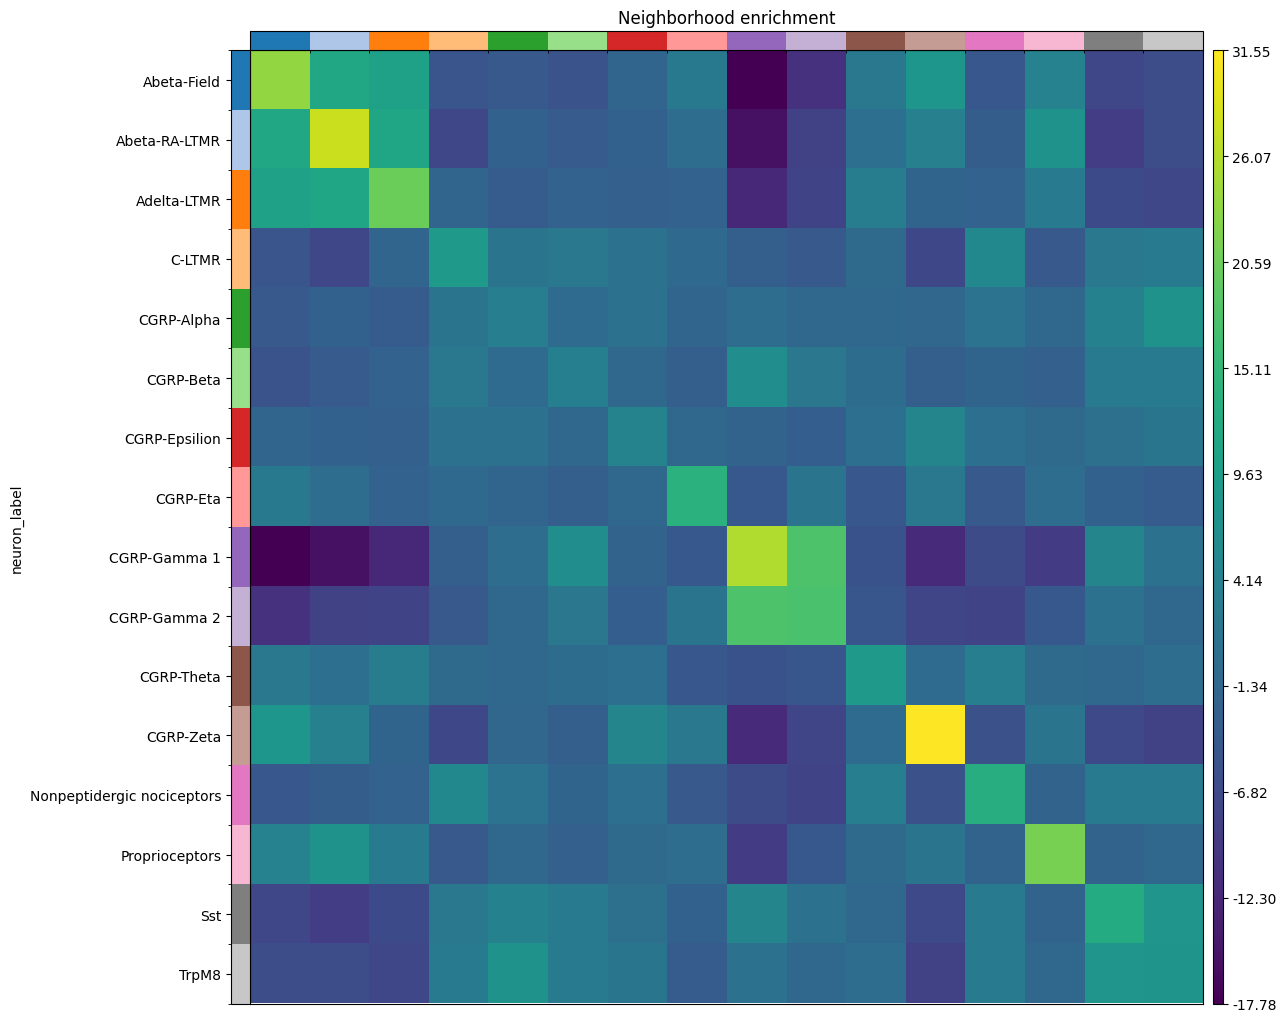

In [64]:
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", show=False)
plt.savefig(os.path.join(plot_out_dir, "neuron_neighborhood_enrichment.pdf"), format='pdf', bbox_inches='tight')

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


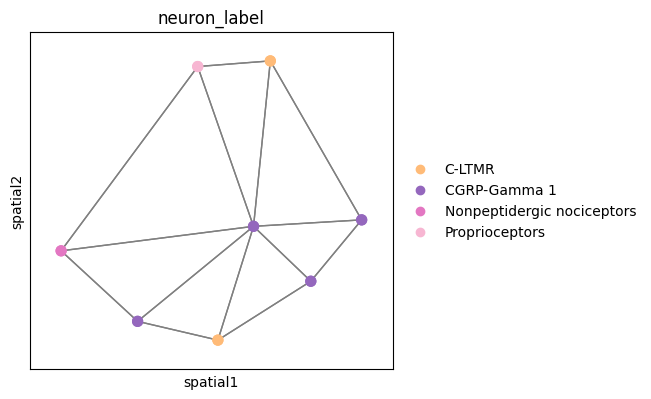

In [66]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 1')[0][0]
for key_added in ['spatial']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )
    plt.savefig(os.path.join(plot_out_dir, "neuron_spatial_connected_neighbor_example_CGRPgamma1.pdf"), format='pdf', bbox_inches='tight')
    

### Run on neurons - try radius based spatial graph

In [29]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 25,
                        key_added = 'spatial_25um',
                        delaunay = False)

In [30]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 50,
                        key_added = 'spatial_50um',
                        delaunay = False)

In [31]:
# run neighbor graph
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample_id', 
                        coord_type = 'generic', 
                        radius = 100,
                        key_added = 'spatial_100um',
                        delaunay = False)

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

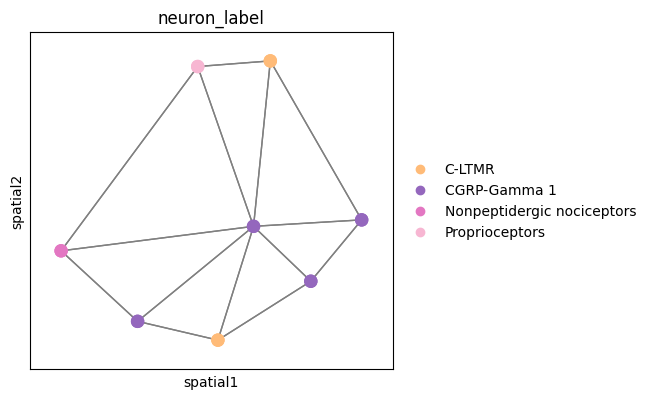

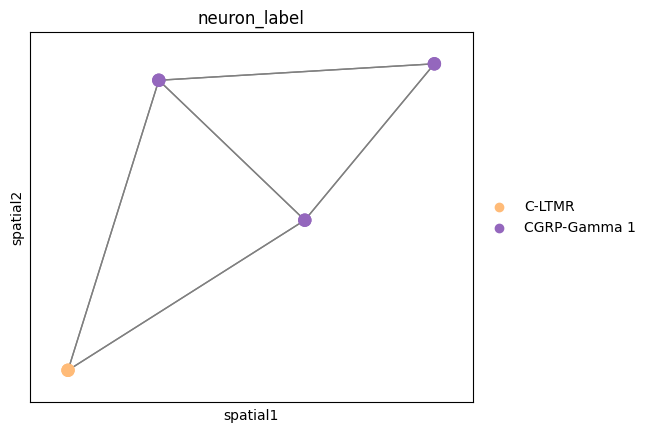

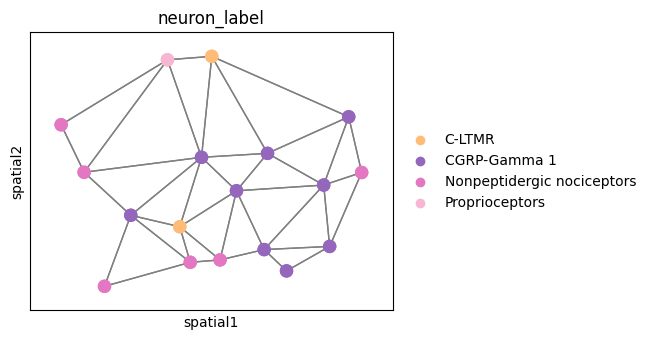

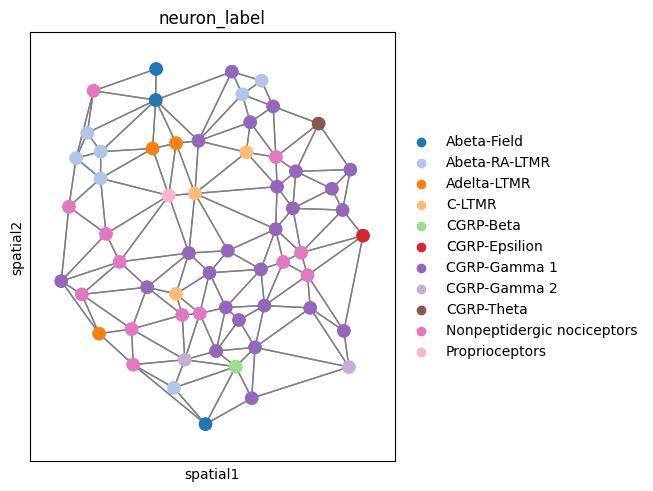

In [32]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 1')[0][0]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=300,
        library_key = 'sample_id',
    )

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

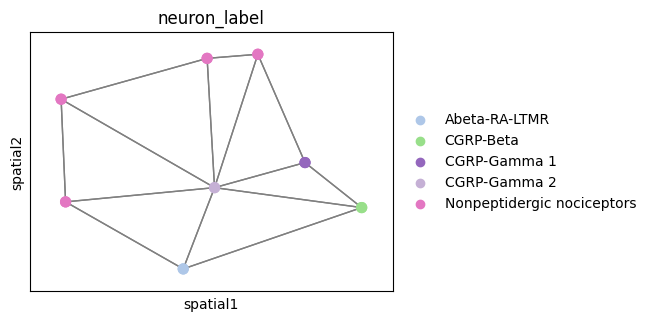

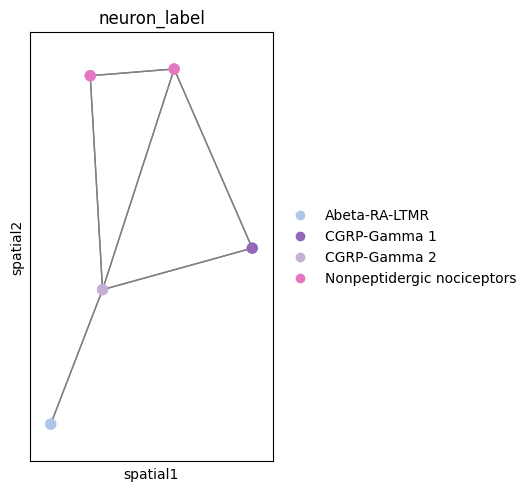

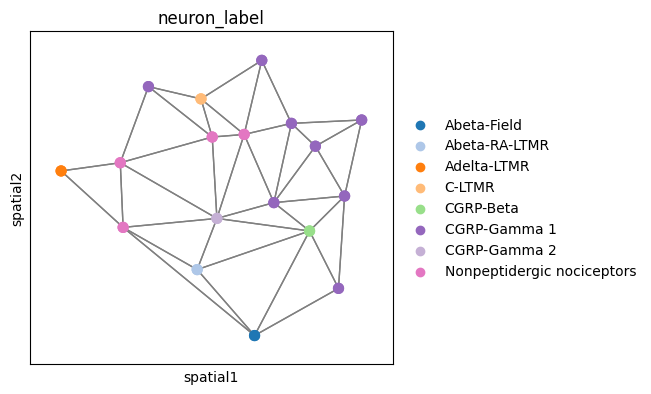

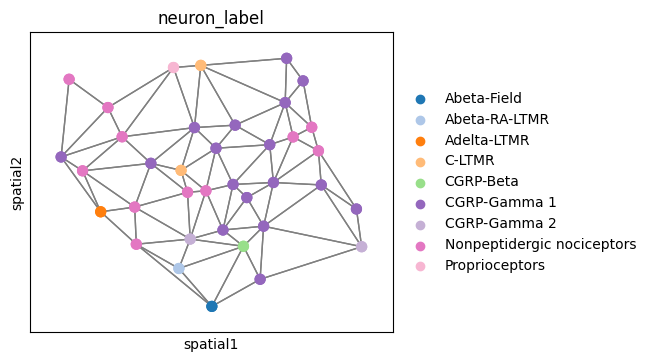

In [33]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Gamma 2')[0][0]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attrib

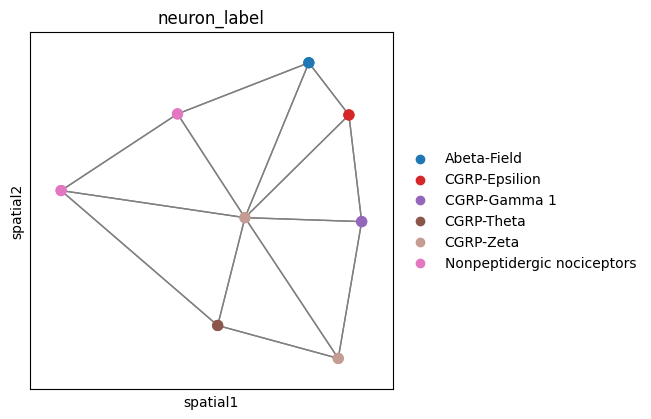

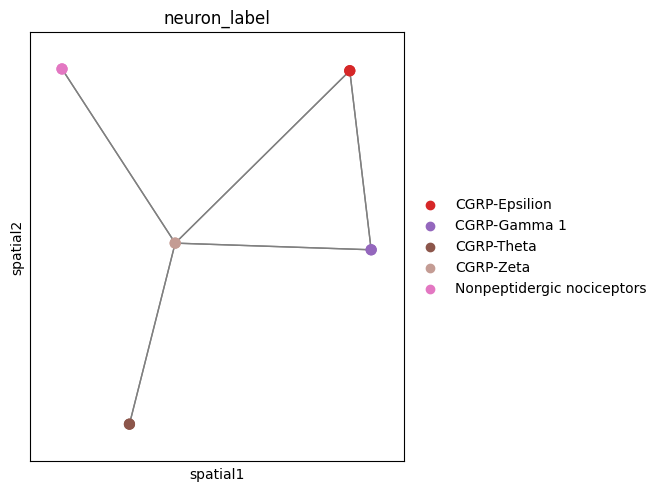

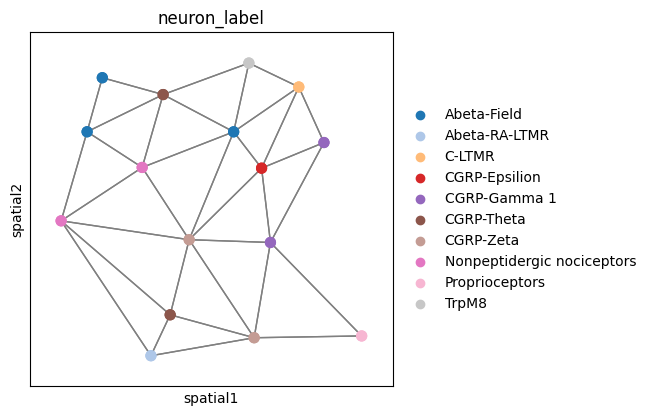

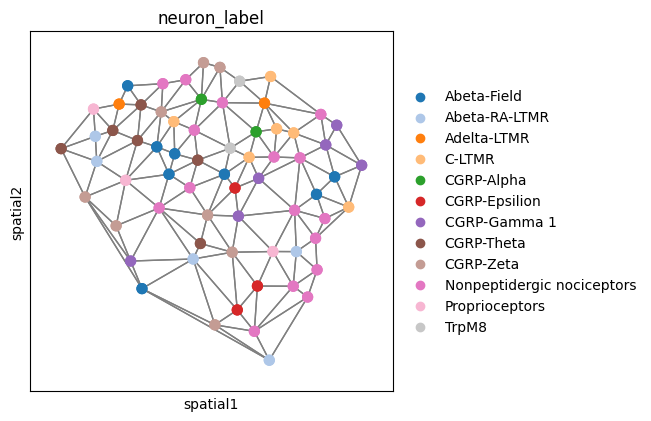

In [38]:
cats = adata.obs["neuron_label"].cat.categories

row = np.where(adata.obs['neuron_label'] == 'CGRP-Zeta')[0][2]
for key_added in ['spatial', 'spatial_25um', 'spatial_50um', 'spatial_100um']:
    _, idx = adata.obsp[f"{key_added}_connectivities"][row, :].copy().nonzero()
    idx = np.append(idx, row)
    sq.pl.spatial_scatter(
        adata[idx, :],
        # spatial_key = 'X_spatial',
        shape=None,
        color="neuron_label",
        connectivity_key='spatial_connectivities',
        size=200,
        library_key = 'sample_id',
    )

100%|██████████| 1000/1000 [00:02<00:00, 450.52/s]


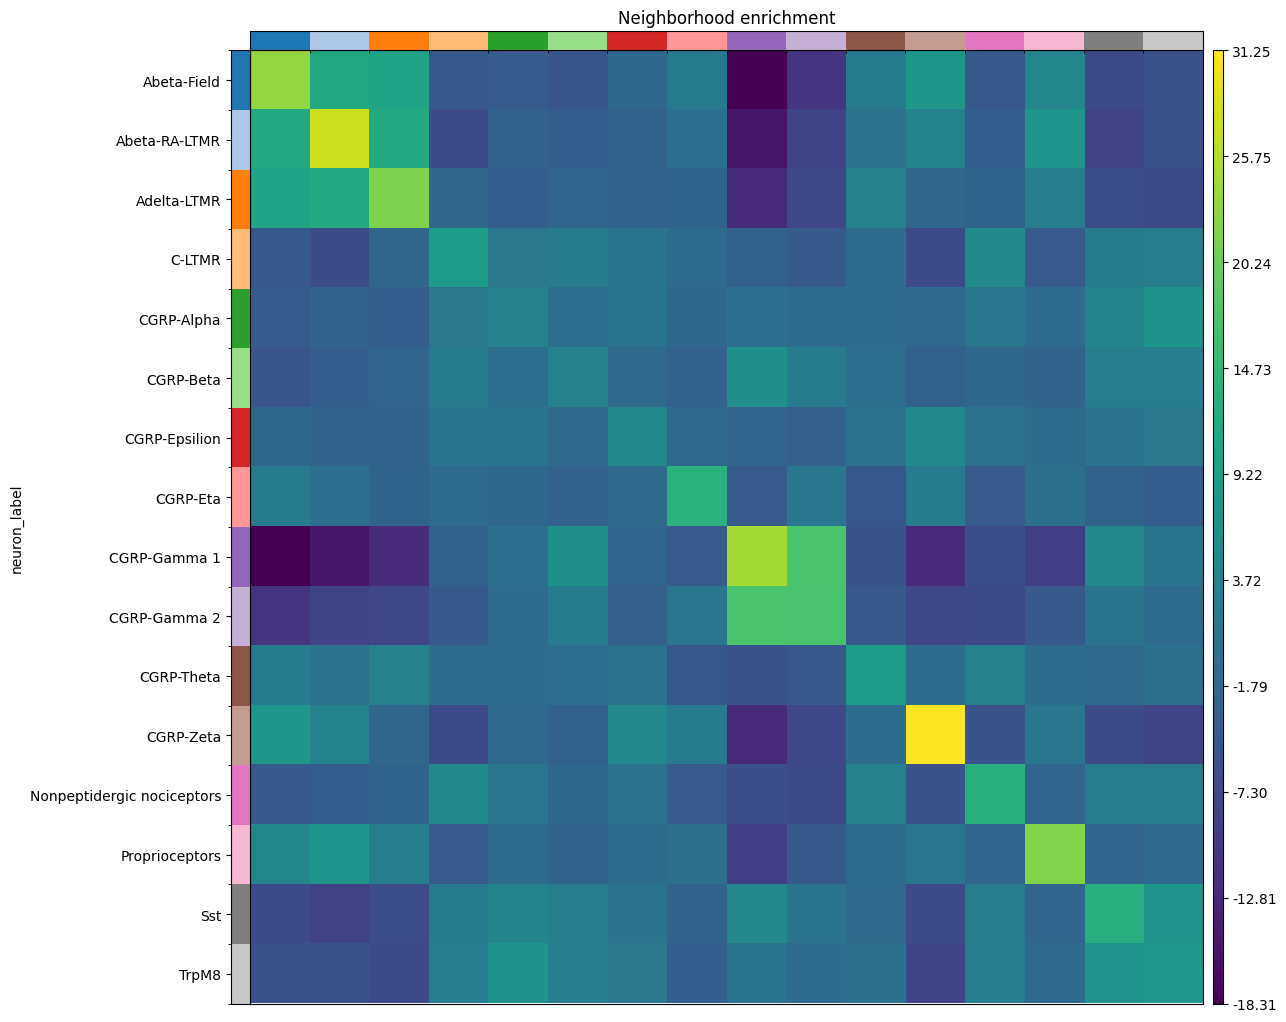

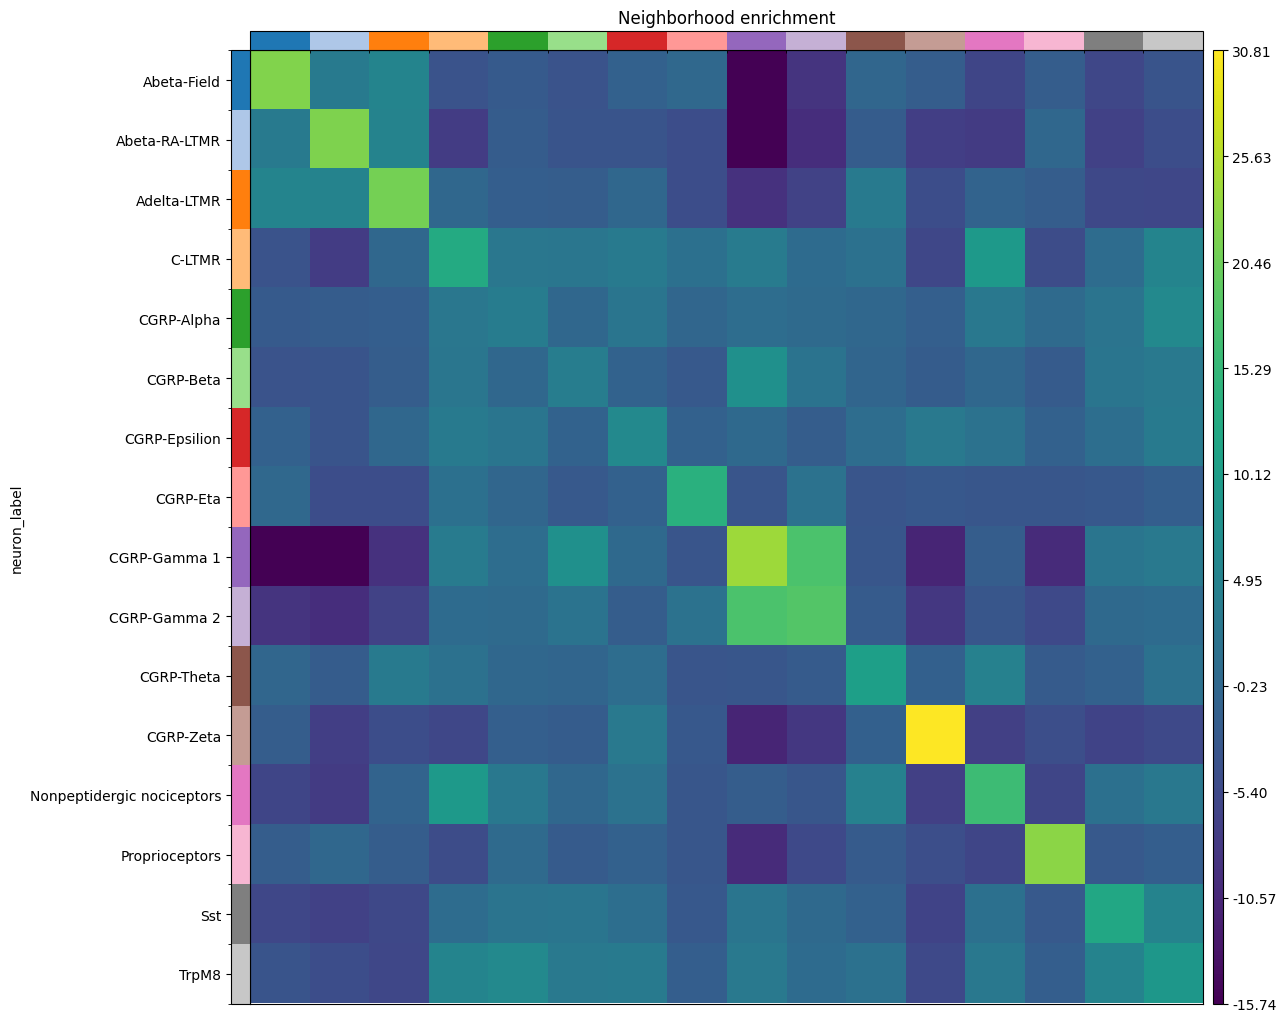

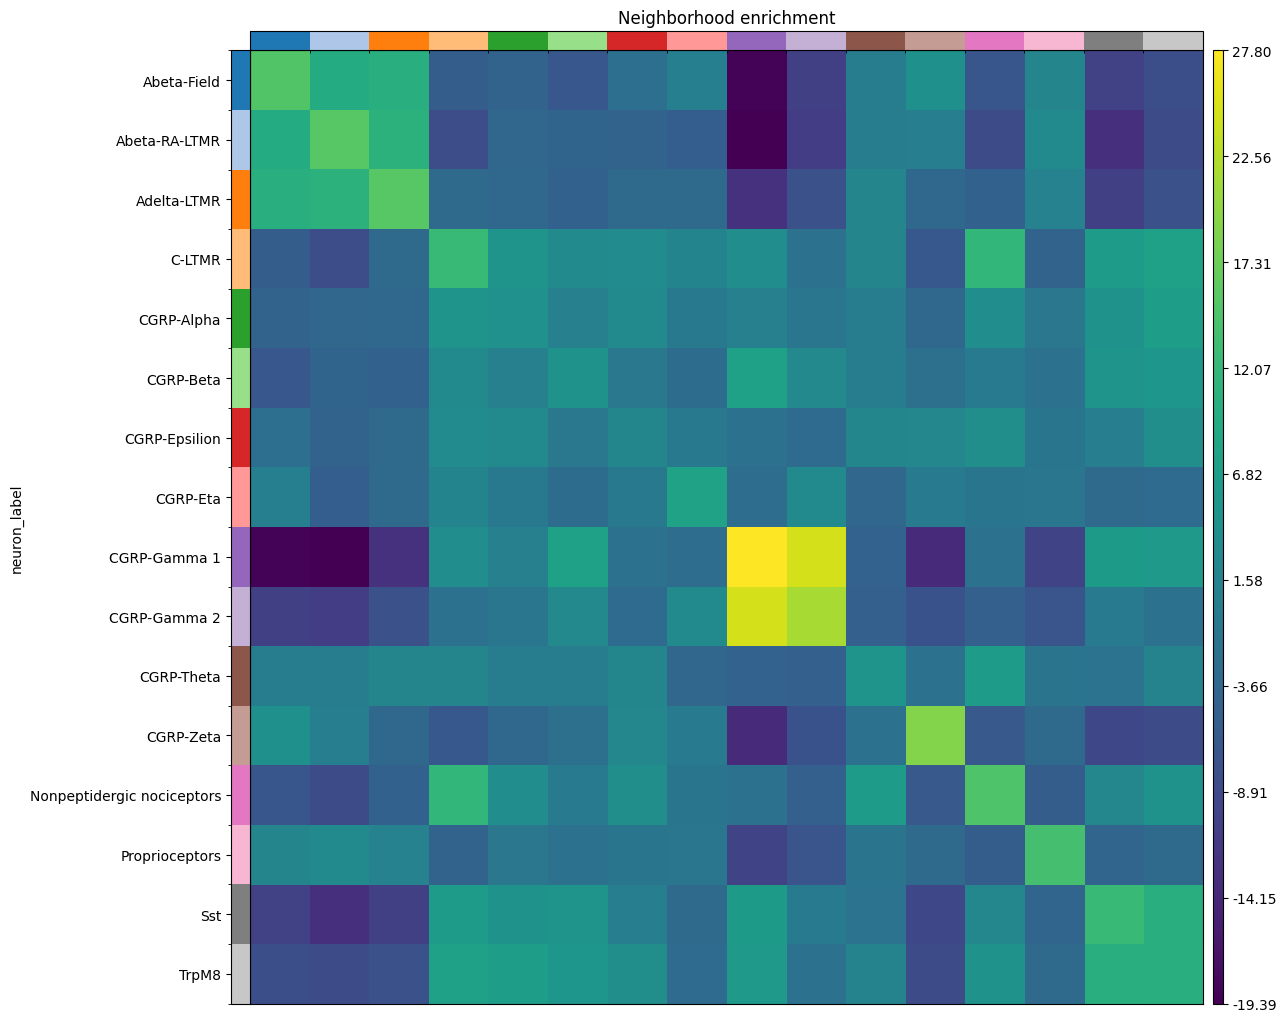

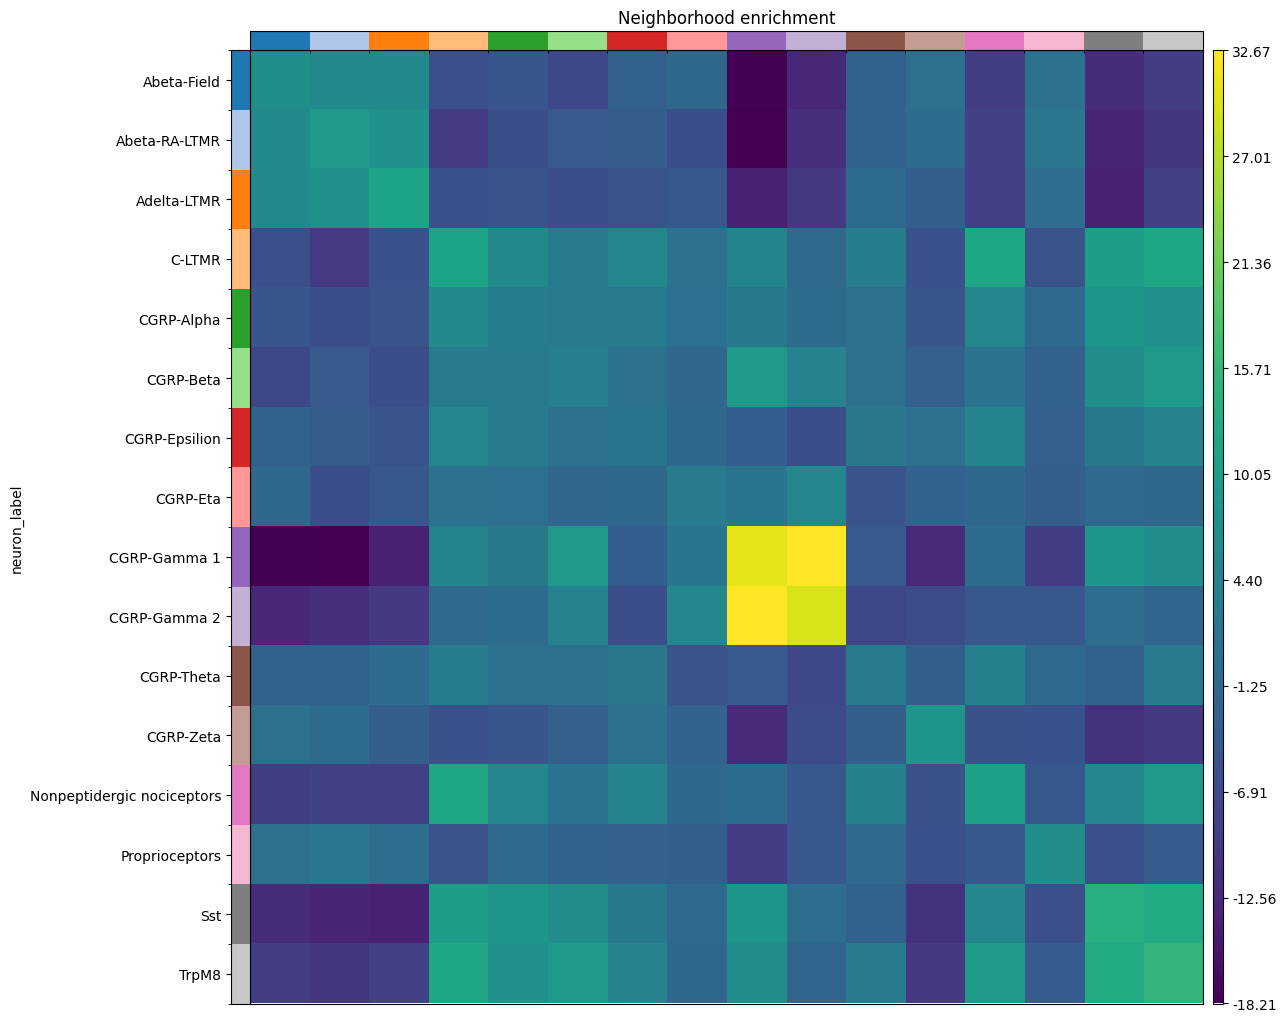

In [35]:
sq.gr.nhood_enrichment(adata, cluster_key="neuron_label" )
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label")

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.nhood_enrichment(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')
sq.pl.nhood_enrichment(adata,cluster_key="neuron_label", connectivity_key = 'spatial_100um')

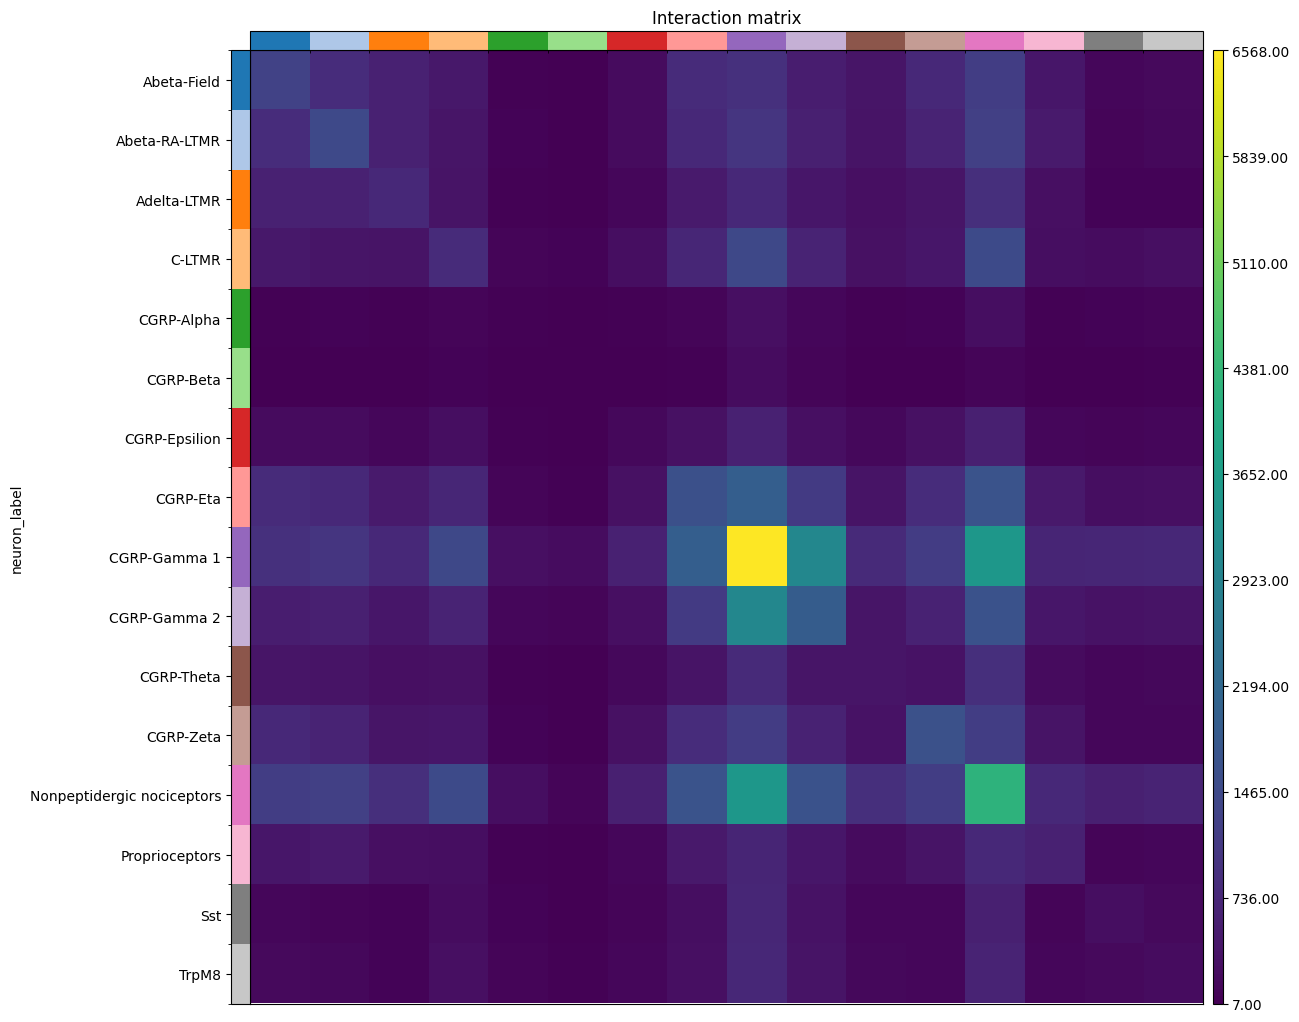

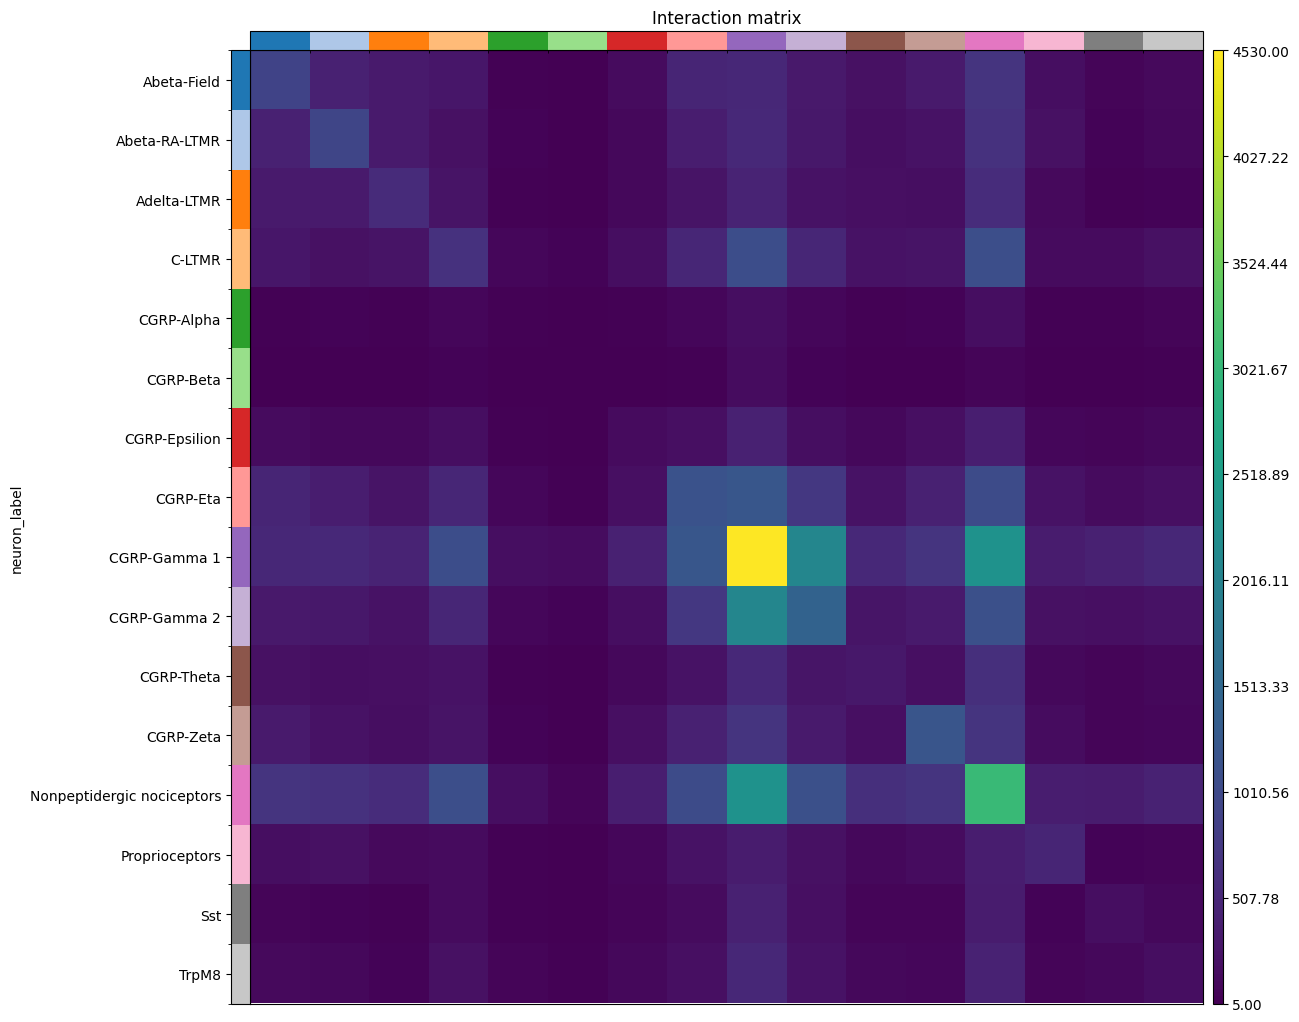

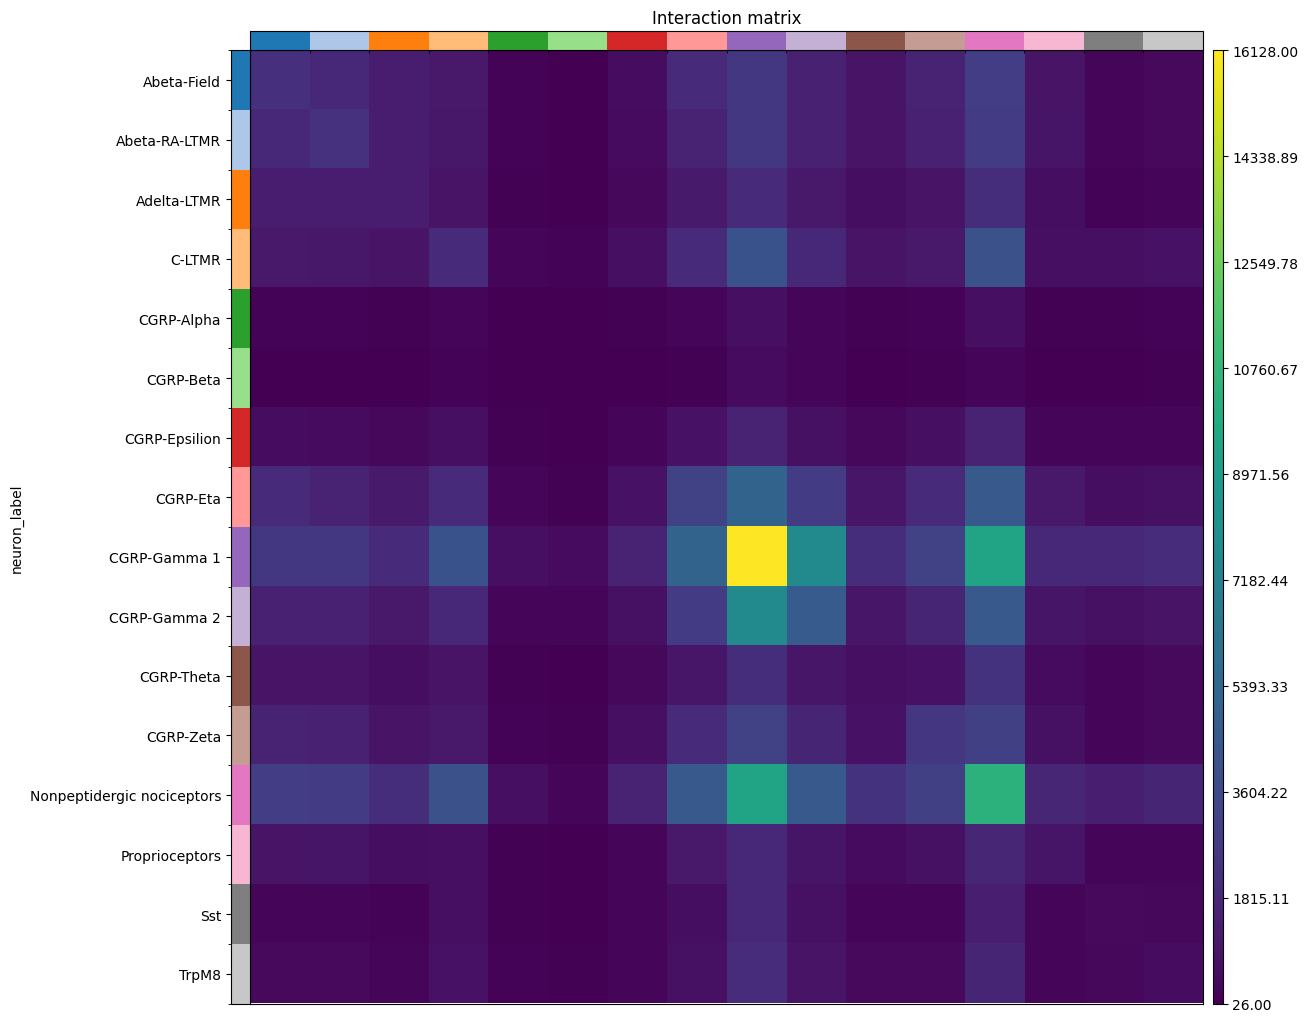

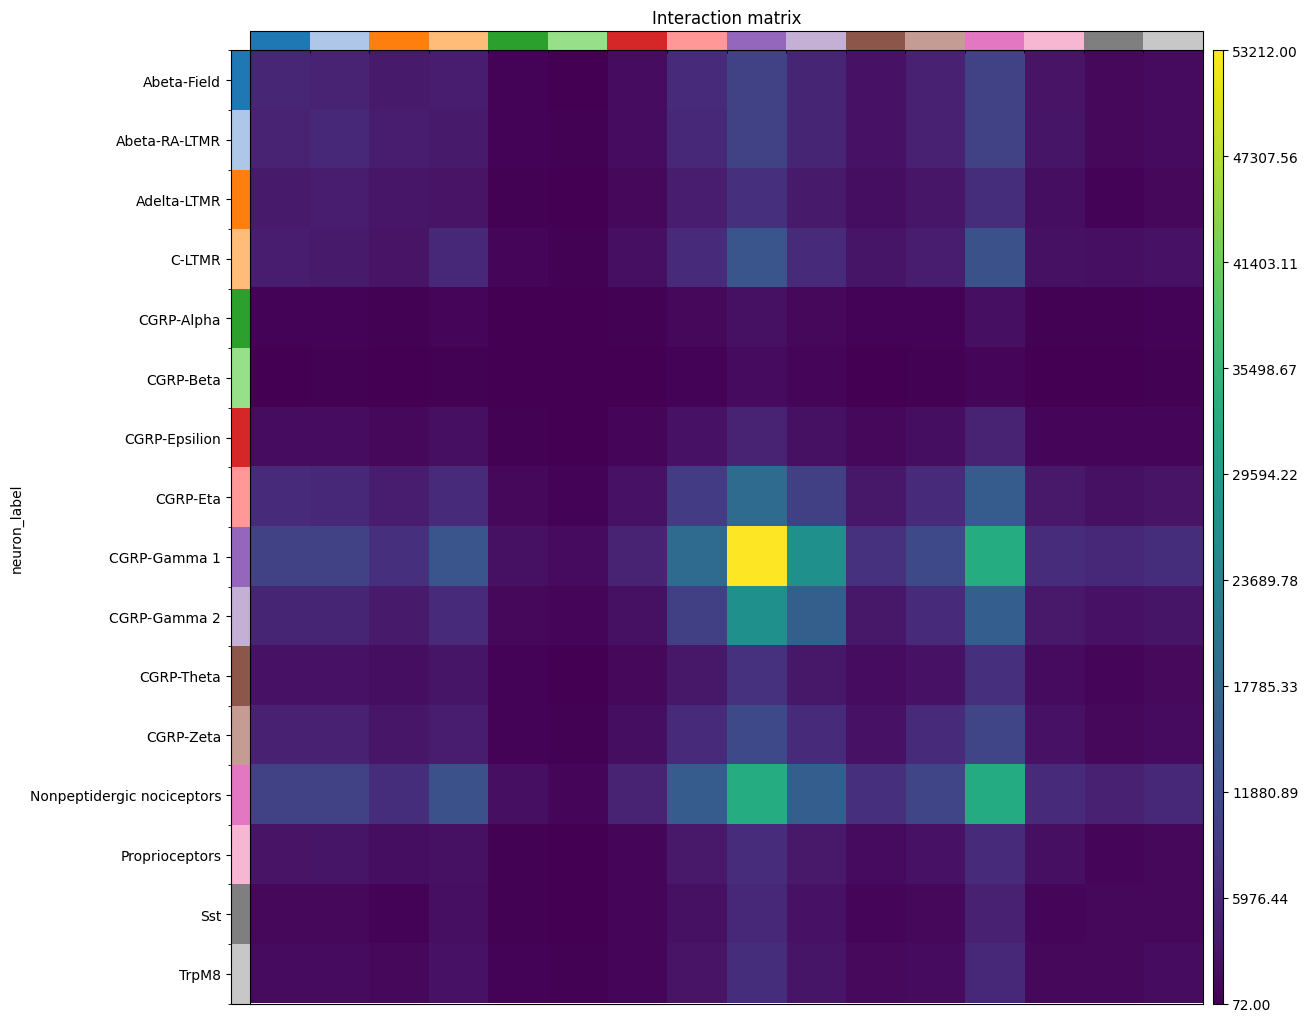

In [36]:
# interaction matrix
sq.gr.interaction_matrix(adata, cluster_key="neuron_label")
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')

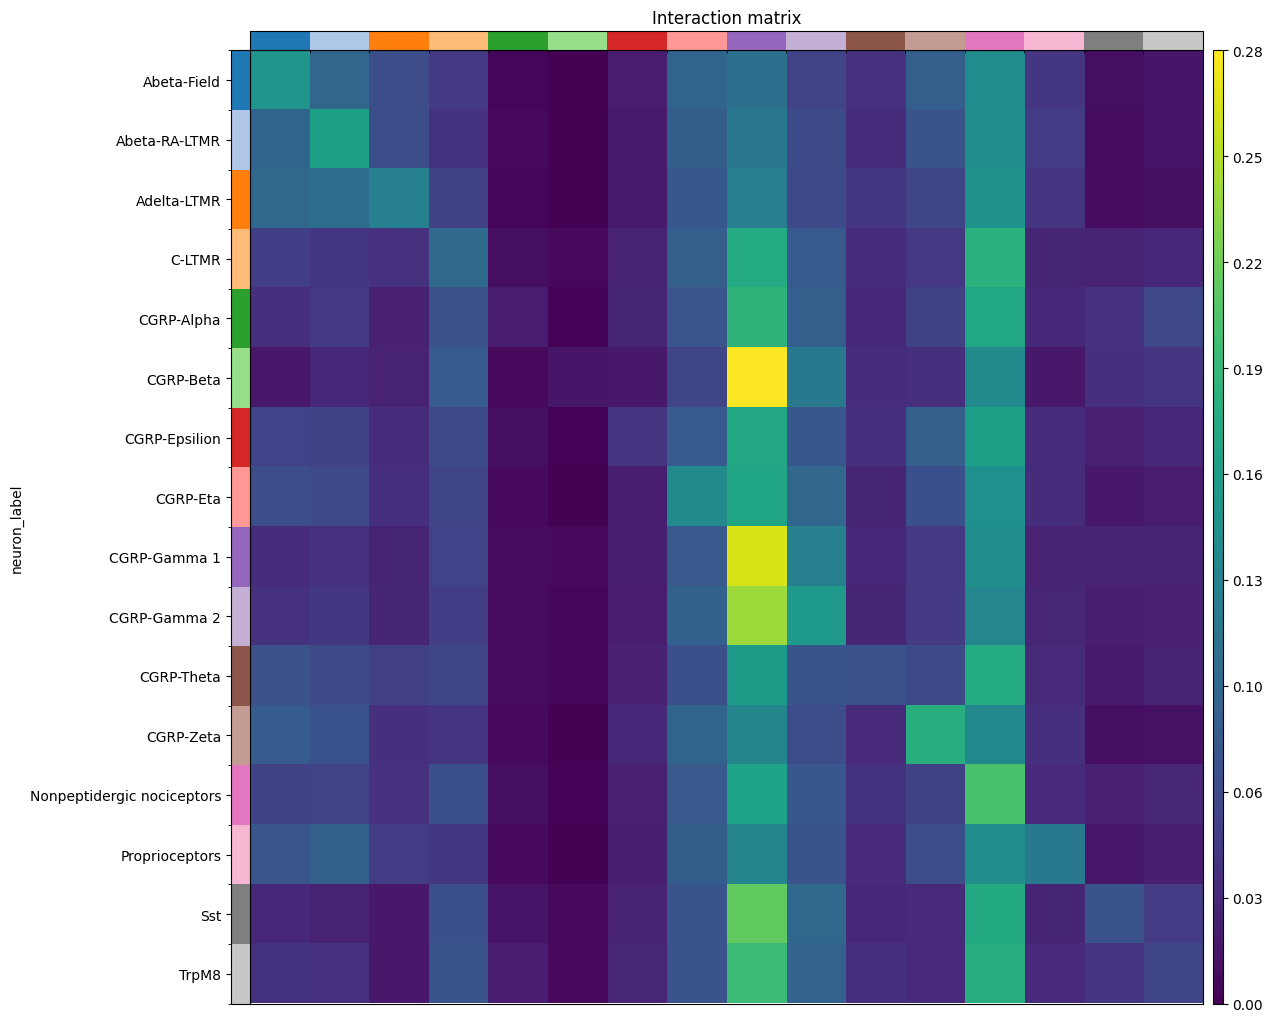

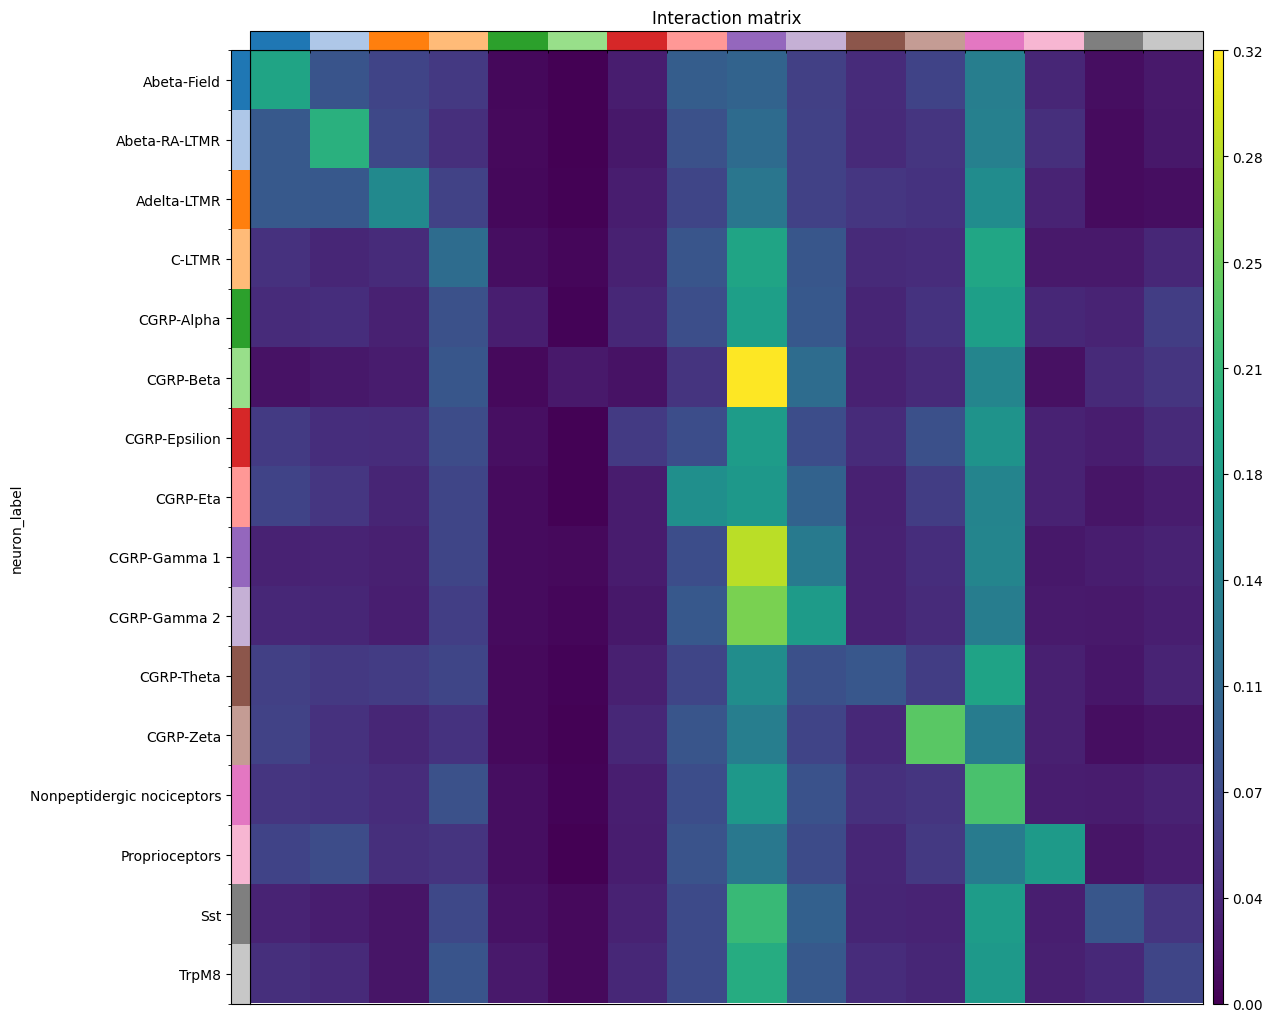

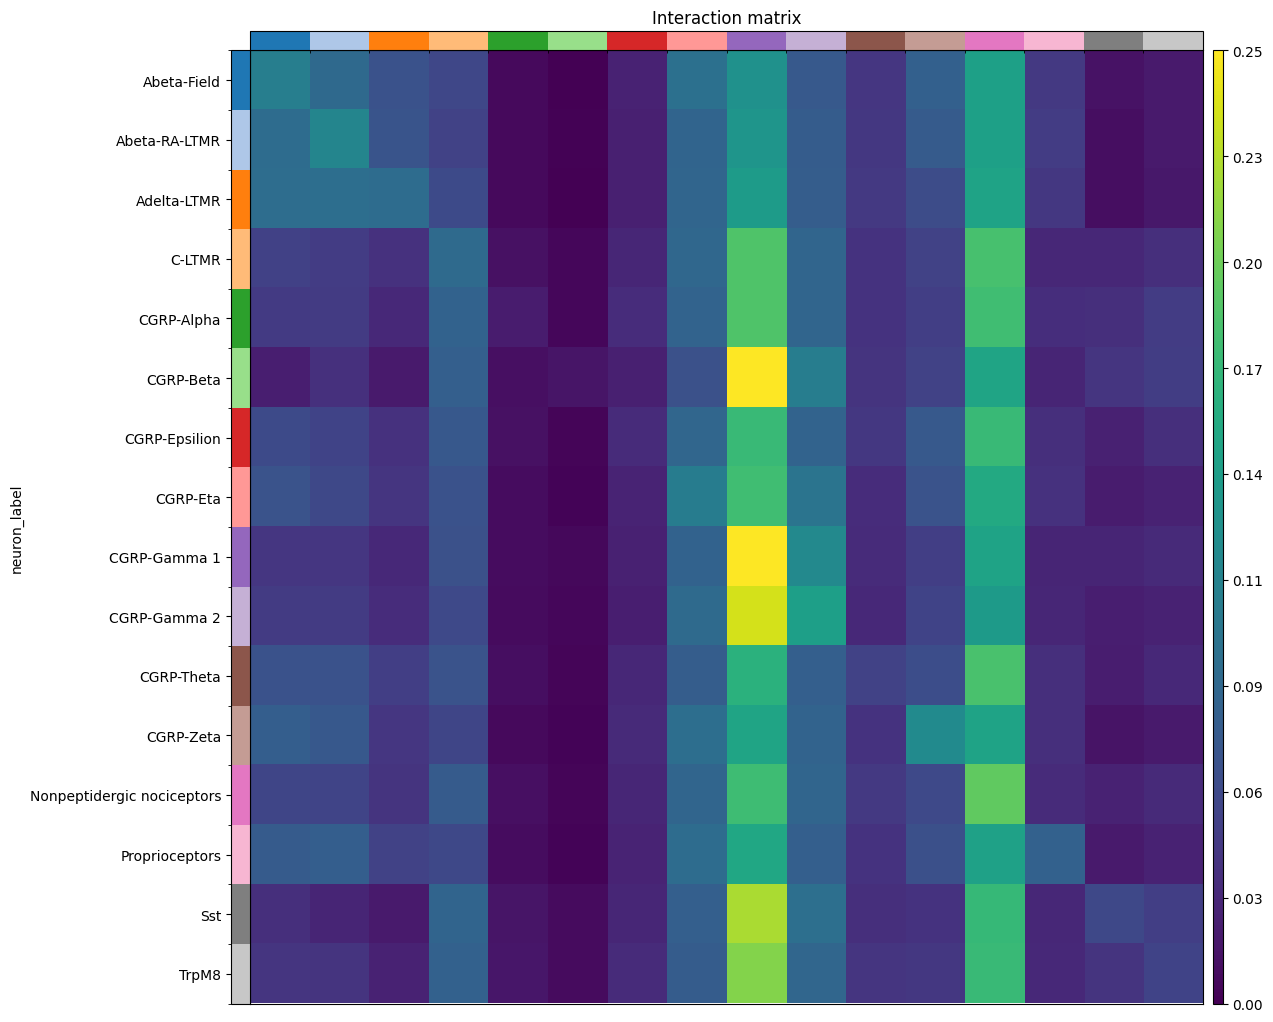

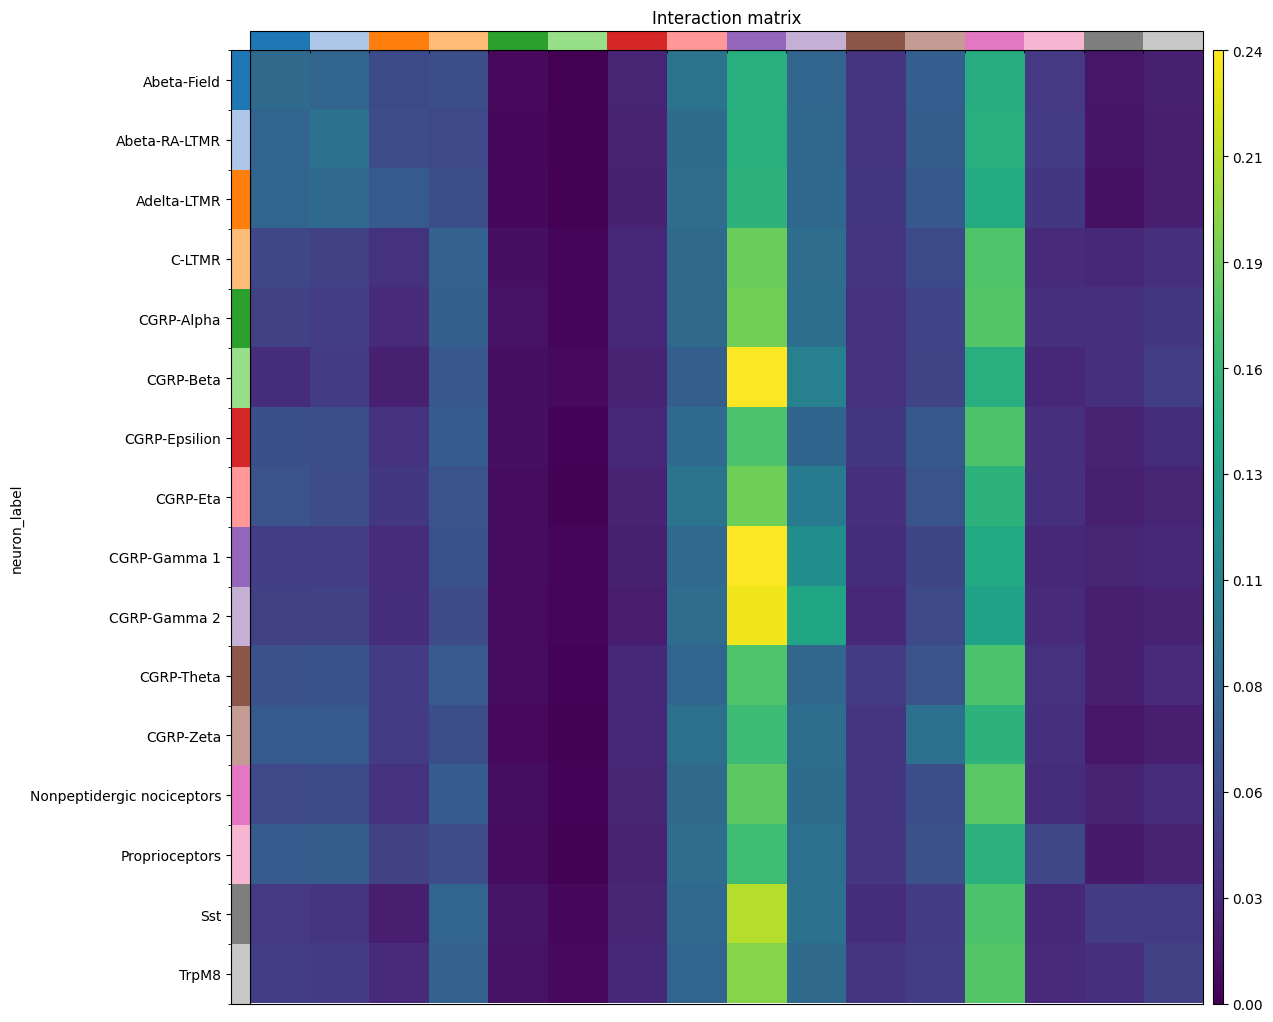

In [37]:
# interaction matrix
sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True)
sq.pl.interaction_matrix(adata, cluster_key="neuron_label")

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_25um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_25um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_50um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_50um')

sq.gr.interaction_matrix(adata, cluster_key="neuron_label", normalized = True,  connectivity_key = 'spatial_100um')
sq.pl.interaction_matrix(adata, cluster_key="neuron_label", connectivity_key = 'spatial_100um')